In [1]:
from impact import Impact

from distgen import Generator

import numpy as np
import os 

ROOT = os.environ['LCLS_LATTICE']

In [2]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (8,4)

In [3]:
ifile = os.path.join(ROOT, 'impact/models/cu_inj/old/ImpactT.in')
gfile = os.path.join(ROOT, 'distgen/models/cu_inj/v0/distgen.yaml')
assert os.path.exists(ifile)
assert os.path.exists(gfile)


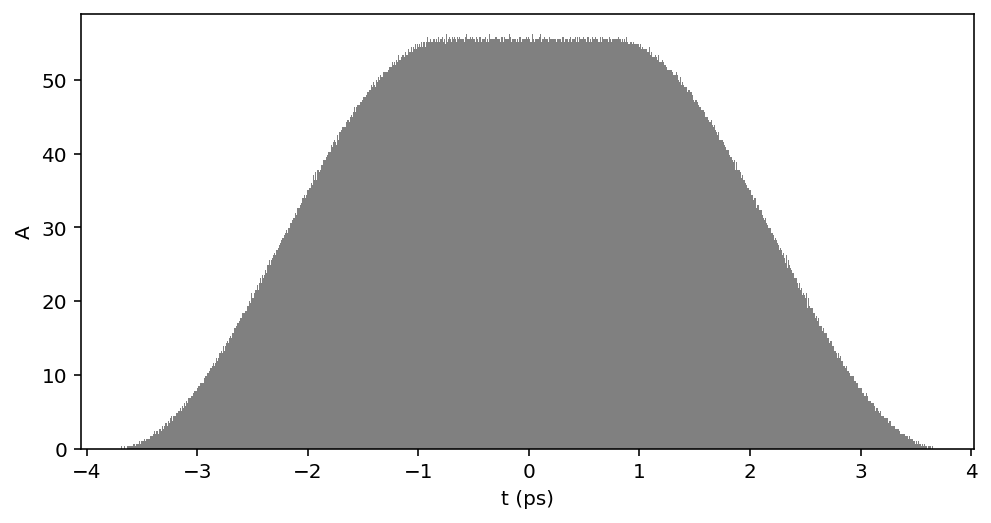

In [4]:
G = Generator(gfile)
G.run()
P0 = G.particles
P0.plot('t')

In [5]:
# Make Impact object
I = Impact(ifile, initial_particles = P0, verbose=True)

Configured to run in: /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp_i3bc0wb


# Autophase

In [6]:
from impact.autophase import autophase_and_scale

from pmd_beamphysics import single_particle

P0 = single_particle(pz=1e-15, z=1e-15)

autophase_and_scale(I, phase_ele_name='GUN', target=6e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=False)

(304.83485070005105, 47541430.82645669)

In [7]:
#  Changes in phases
I.add_group('L0A', ele_names=['L0A_entrance', 'L0A_body_1', 'L0A_body_2', 'L0A_exit'], var_name='theta0_deg', attributes='theta0_deg')
I.add_group('L0B', ele_names=['L0B_entrance', 'L0B_body_1', 'L0B_body_2', 'L0B_exit'], var_name='theta0_deg', attributes='theta0_deg')

# Overall scaling, respecting the special factors. 
I.add_group('L0A_scale', ele_names=['L0A_entrance', 'L0A_body_1', 'L0A_body_2', 'L0A_exit'],
                   var_name = 'rf_field_scale',
                  factors = [0.86571945106805, 1, 1, 0.86571945106805],  # sin(k*d) with d = 3.5e-2 m 
                  absolute=True)

# Overall scaling, respecting the special factors. 
I.add_group('L0B_scale', ele_names=['L0B_entrance', 'L0B_body_1', 'L0B_body_2', 'L0B_exit'],
                   var_name = 'rf_field_scale',
                  factors = [0.86571945106805, 1, 1, 0.86571945106805],  # sin(k*d) with d = 3.5e-2 m 
                  absolute=True)

I['L0A_scale']['rf_field_scale'] = 30e6
I['L0A_scale']




ControlGroup(**{"ele_names": ["L0A_entrance", "L0A_body_1", "L0A_body_2", "L0A_exit"], "var_name": "rf_field_scale", "attributes": ["rf_field_scale", "rf_field_scale", "rf_field_scale", "rf_field_scale"], "factors": [0.86571945106805, 1, 1, 0.86571945106805], "reference_values": [25905612.0, 29913224.7, 29913224.7, 25905612.0], "absolute": true, "value": 30000000.0})

In [8]:
# L0A to 64 MeV
autophase_and_scale(I, phase_ele_name='L0A', scale_ele_name='L0A_scale', target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=False)

(9.197730665862807, 30048347.300712895)

In [10]:
# L0B to 135 MeV
autophase_and_scale(I, phase_ele_name='L0B', scale_ele_name='L0B_scale', target=135e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=False)

(359.9999944625912, 36780527.390095934)

In [13]:
I.verbose=False
I.track(P0, s=8.371612)['mean_energy']

134999242.34121263

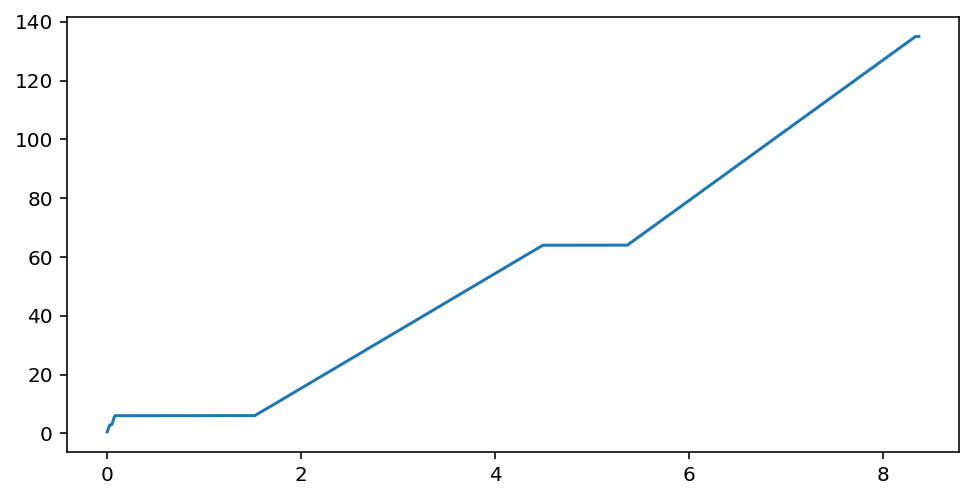

In [12]:
plt.plot(I.stat('mean_z'), I.stat('mean_kinetic_energy')/1e6 + 0.511)

# Parallel run

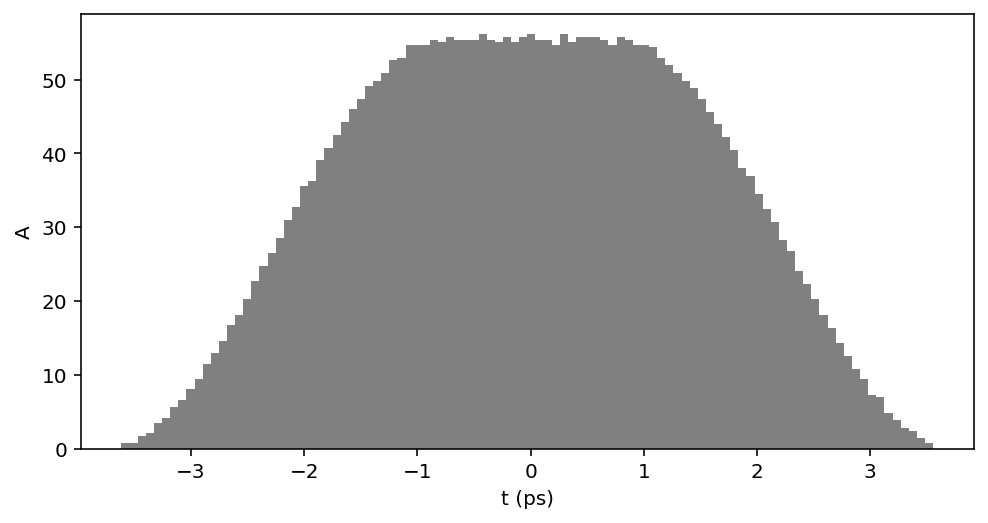

In [15]:
G = Generator(gfile)
G['n_particle'] = 10000
G.run()
P0 = G.particles
P0.plot('t')

================ Impact-T Summary ================    
10000 particles
1 bunch of electrons
total charge: 249.99999999999997 pC
Distribution type: read
Cathode start at z = 0 m
   emission time: 1.4e-11 s
   image charges neglected after z = 0.02 m
Processor domain: 1 x 1 = 1 CPUs
Space charge grid: 16 x 16 x 16
Maximum time steps: 1000000
Reference Frequency: 2856000000.0 Hz
Initial reference time: 0.0 s
Simulation starting from the beginning

Configured to run in: /Users/chrisonian/Scratch/temp


In [25]:
I = Impact(ifile, initial_particles = P0, verbose=False, use_tempdir=False, workdir='/Users/chrisonian/Scratch/temp')

# Make new elements
def new_write_beam(s, i, sample_frequency=1):
    if i in [40, 50]:
        print('Warning: will overwrite standard output files')
    ele = {'type':'write_beam', 'sample_frequency':sample_frequency}
    ele['filename'] = 'fort.'+str(i)
    ele['name'] = 'write_beam_'+str(i)
    ele['s'] = s
    return ele
def new_write_beams(slist, istart, sample_frequency=1):
    eles = []
    if len(slist) > 100:
        print('Warning: the maximum number of phase-space files which can be output is 100.')
    i = istart
    for s in slist:
        ele = new_write_beam(s, i, sample_frequency)
        eles.append(ele)
        i += 1
    return eles
slist = np.linspace(0.001,4, 99)
neweles = new_write_beams(slist, 100)

In [22]:
# Change some things
I.header['Nx'] = 64
I.header['Ny'] = 64
I.header['Nz'] = 128
I.header['Dt'] = 5e-13
I.stop = 15

# Set parallel domain
I.header['Npcol'] = 4
I.header['Nprow'] = 8

# Turn on MPI switches
I.use_mpi=True
I.impact_bin = '$IMPACTT_MPI_BIN'
I.mpi_exe = 'mpirun' 

I.write_input()

Removed element: stop_1
Set stop to s = 15
writing 10000 particles to /Users/chrisonian/Scratch/temp/partcl.data
Cathode start with cathode_kinetic_energy_ref = 1.0 eV
Cathode start: Replaced Np with 10000 according to initial particles
Cathode start: Replaced Bkenergy with 1.0 according to initial particles
Cathode start: Replaced Temission with 7.183946503142835e-12 according to initial particles
Cathode start: Replaced Tini with -3.5632234226414296e-12 according to initial particles
Setting total charge to 2.4999999999999996e-10 C
